# EDA ECOMMERCE CHURN
## FUENTE : https://www.kaggle.com/datasets/upam22/ecommerce-customer-churn-data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%run '/content/pandas_missing_extension.ipynb'

In [3]:
data_df = pd.read_csv('/content/ecom_data.csv')
data_df

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,151
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,225
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,179


In [4]:
data_df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [5]:
import re

def to_snake_case(name):
    # Insert an underscore before any uppercase letter that is not at the start of the string
    name = re.sub(r'(?<!^)(?=[A-Z])', '_', name)
    return name.lower()

data_df.columns = [to_snake_case(col) for col in data_df.columns]

In [ ]:
data_df

,customer_i_d,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,151
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,225
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,179


# TRATAMIENTO DE DATOS FALTANTES

In [6]:
data_df.missing.number_complete()

np.int64(110744)

In [7]:
data_df.missing.missing_variable_summary()

,variable,n_missing,n_cases,pct_missing
0,customer_i_d,0,5630,0.000000
1,churn,0,5630,0.000000
2,tenure,264,5630,4.689165
3,preferred_login_device,0,5630,0.000000
4,city_tier,0,5630,0.000000
5,warehouse_to_home,251,5630,4.458259
6,preferred_payment_mode,0,5630,0.000000
7,gender,0,5630,0.000000
8,hour_spend_on_app,255,5630,4.529307
9,number_of_device_registered,0,5630,0.000000


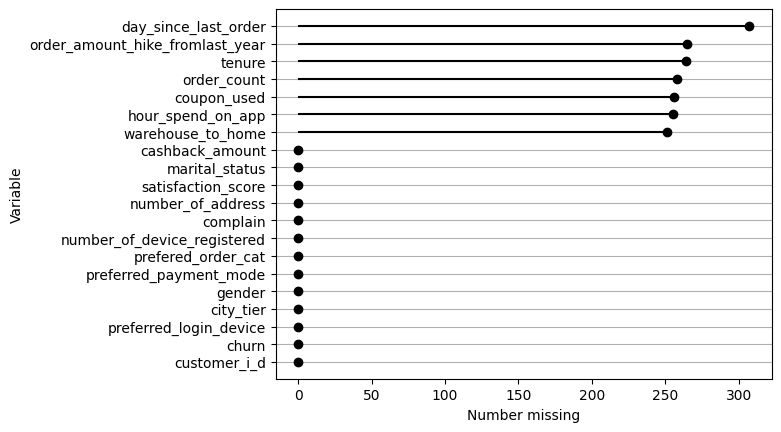

In [8]:
data_df.missing.missing_variable_plot()

<Axes: >

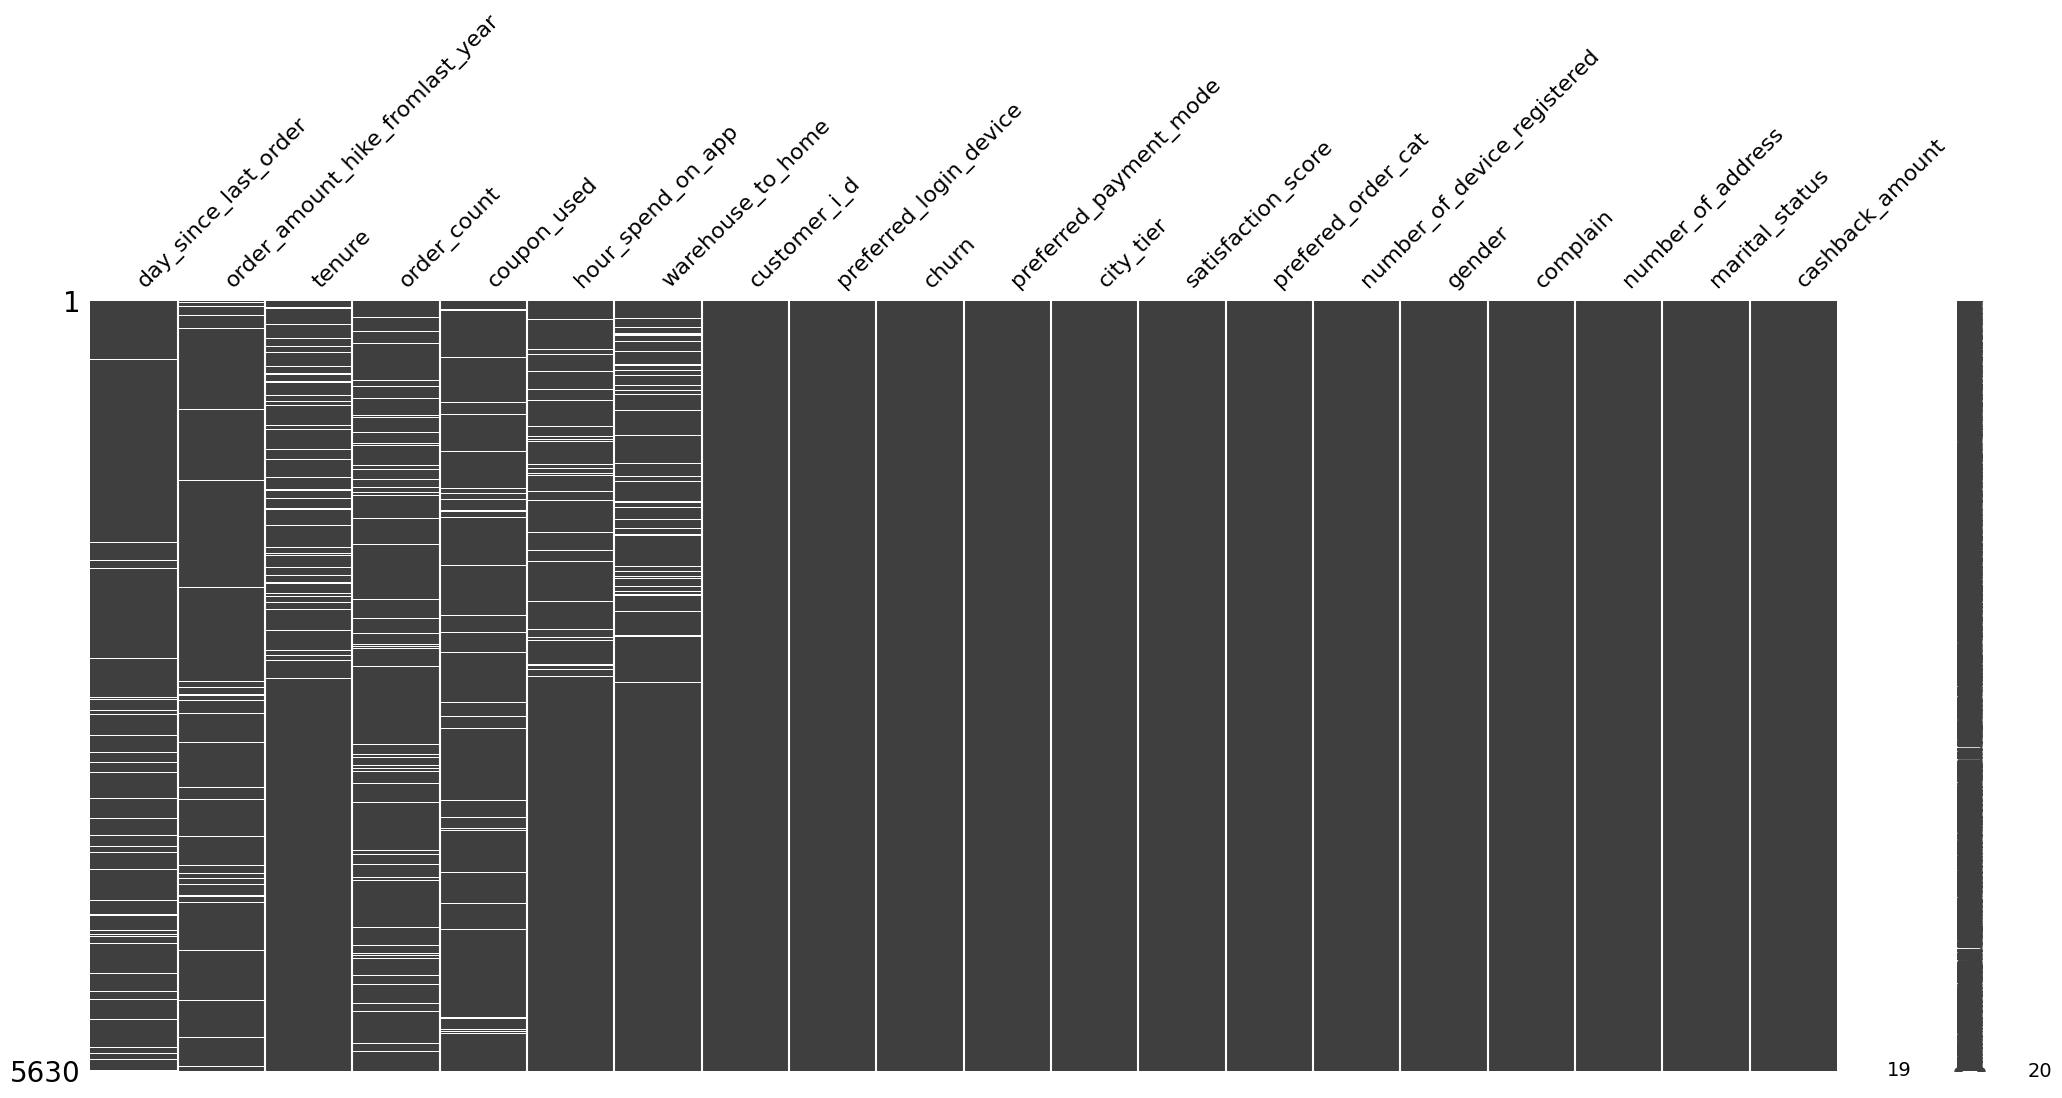

In [9]:
import missingno

data_df.missing.sort_variables_by_missingness().pipe(missingno.matrix)

# EJERCICIOS A REALIZAR

## 1 - IMPUTAR TODOS LOS DATOS FALTANTES

# IDENTIFICAR VARIABLES NÚMERICAS Y CATEGORICAS

In [11]:
missing_summary = data_df.missing.missing_variable_summary()
missing_columns = missing_summary[missing_summary['pct_missing'] > 0]['variable'].tolist()

print("Columns with missing values:")
print(missing_columns)

Columns with missing values:
['tenure', 'warehouse_to_home', 'hour_spend_on_app', 'order_amount_hike_fromlast_year', 'coupon_used', 'order_count', 'day_since_last_order']


In [12]:
print("Data types of columns with missing values:")
print(data_df[missing_columns].dtypes)

Data types of columns with missing values:
tenure                             float64
warehouse_to_home                  float64
hour_spend_on_app                  float64
order_amount_hike_fromlast_year    float64
coupon_used                        float64
order_count                        float64
day_since_last_order               float64
dtype: object


In [15]:
numerics_nan = ['tenure', 'warehouse_to_home', 'hour_spend_on_app', 'order_amount_hike_fromlast_year', 'coupon_used', 'order_count', 'day_since_last_order']

In [14]:
df_cleaned = data_df.copy()

In [16]:
for variable in numerics_nan:
  df_cleaned[variable] = df_cleaned[variable].fillna(float(round(df_cleaned[variable].mean())))

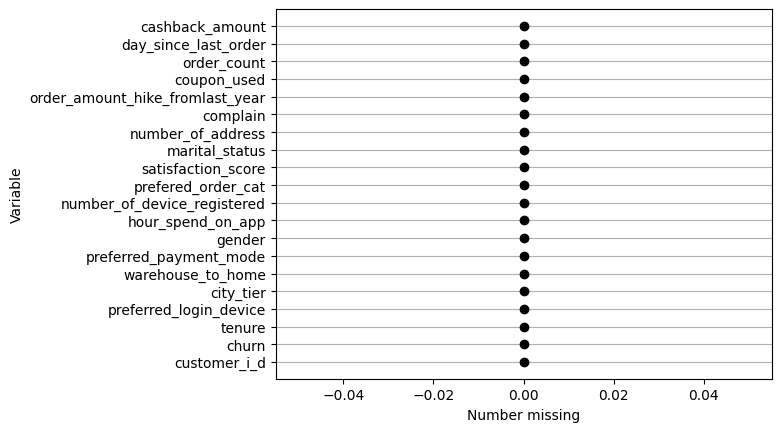

In [17]:
df_cleaned.missing.missing_variable_plot()